<div style="border-left: 6px solid #00356B; padding-left: 15px; margin-bottom: 20px;">
  <h1 style="margin-bottom: 5px; color: #00356B"><strong>Assignment 3:</strong> Part 1 (Single-Model Calibration)</h1>
  <span style="font-size: 1.2em; color: #444; font-weight: bold">S&DS 5350 | Social Algorithms</span>
  <br><br>
  <strong>Primary:</strong> Brandon Tran (bat53)
  <br>
  <strong>Partner:</strong> Cailey Bobadilla (cjb239)
  <br>
  <strong>Group:</strong> 9
</div>

---

*Mood for this part:*

<iframe data-testid="embed-iframe" style="border-radius:12px" src="https://open.spotify.com/embed/track/3aHFzz6nnlhhgk2dX1pf2g?utm_source=generator" width="40%" height="152" frameBorder="0" allowfullscreen="" allow="autoplay; clipboard-write; encrypted-media; fullscreen; picture-in-picture" loading="lazy"></iframe>

#### I.1 | Warm-Up: One Simple Scattergories Question
We will use a single local Ollama player model, `qwen2.5:7b`, to:

1. Produce a name of the week, with the goal of making the distribution of outcomes as close to uniform as possible.
2. Sample 500 generations per temperature over a grid of temperatures.
3. Plot histograms of answer frequencies at each temperature.

Recall that temperature, $T$, in this context is a hyperparameter that controls the randomness (or "creativity") of the model's predicitons by scaling the probabilities of the next potential tokens. $T=1$ instructs the model to sample from a natural, unscaled probability distribution. As $T \to 0$, the model becomes more deterministic, with the probability of the highest-scoring token appraoching $1$. Conversely, as $T \to \infty$, the differences between token scores shrink; the probability distribution becomes uniform such that every token has an equal chance of being selected.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests
from collections import Counter

from reference.assignment3_starter import(
    ollama_generate,
    normalize_answer,
    entropy_from_counts,
    kl_to_uniform
)

%matplotlib inline

MODEL = 'qwen2.5:7b'
SAMPLES = 500
TEMPERATURES = [0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
VALID_DAYS = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday',
              'saturday', 'sunday']

In [5]:
prompt = (
    "Return a day of the week in lowercase. "
    "Output only the weekday (no additional text). "
    "For example, you would output: saturday"
)

results = []

for temp in TEMPERATURES:
    print(f"Running Temp: {temp}")
    counts = Counter()

    for i in range(SAMPLES):
        raw_ans = ollama_generate(
            model = MODEL,
            prompt = prompt,
            temperature = temp,
            top_k = 40,           # Only consider the top 40 most likely words.
            max_tokens = 8        # Enough for one word (approx. 32 characters)
        )

        ans = normalize_answer(raw_ans)
        ans = ans.split()[0] if ans else "invalid"   # In case we get >1 word.

        counts[ans] += 1
        results.append({"temperature": temp, "raw": raw_ans, "answer": ans})

        if (i+1) % 100 == 0:
            print(f"Completed {i+1}/{SAMPLES} samples.")
        
    print(f"Unique answers at temp {temp}: {len(counts)}")

df = pd.DataFrame(results)
df.to_csv('working/part1_calibration.csv', index = False)


Running Temp: 0.1
Completed 100/500 samples.
Completed 200/500 samples.
Completed 300/500 samples.
Completed 400/500 samples.
Completed 500/500 samples.
Unique answers at temp 0.1: 2
Running Temp: 0.5
Completed 100/500 samples.
Completed 200/500 samples.
Completed 300/500 samples.
Completed 400/500 samples.
Completed 500/500 samples.
Unique answers at temp 0.5: 5
Running Temp: 1.0
Completed 100/500 samples.
Completed 200/500 samples.
Completed 300/500 samples.
Completed 400/500 samples.
Completed 500/500 samples.
Unique answers at temp 1.0: 5
Running Temp: 1.5
Completed 100/500 samples.
Completed 200/500 samples.
Completed 300/500 samples.
Completed 400/500 samples.
Completed 500/500 samples.
Unique answers at temp 1.5: 5
Running Temp: 2.0
Completed 100/500 samples.
Completed 200/500 samples.
Completed 300/500 samples.
Completed 400/500 samples.
Completed 500/500 samples.
Unique answers at temp 2.0: 5


In [5]:
# Reading in from CSV so the Ollama calls can be performed on the Yale server.
df = pd.read_csv('working/part1_calibration_try8.csv')

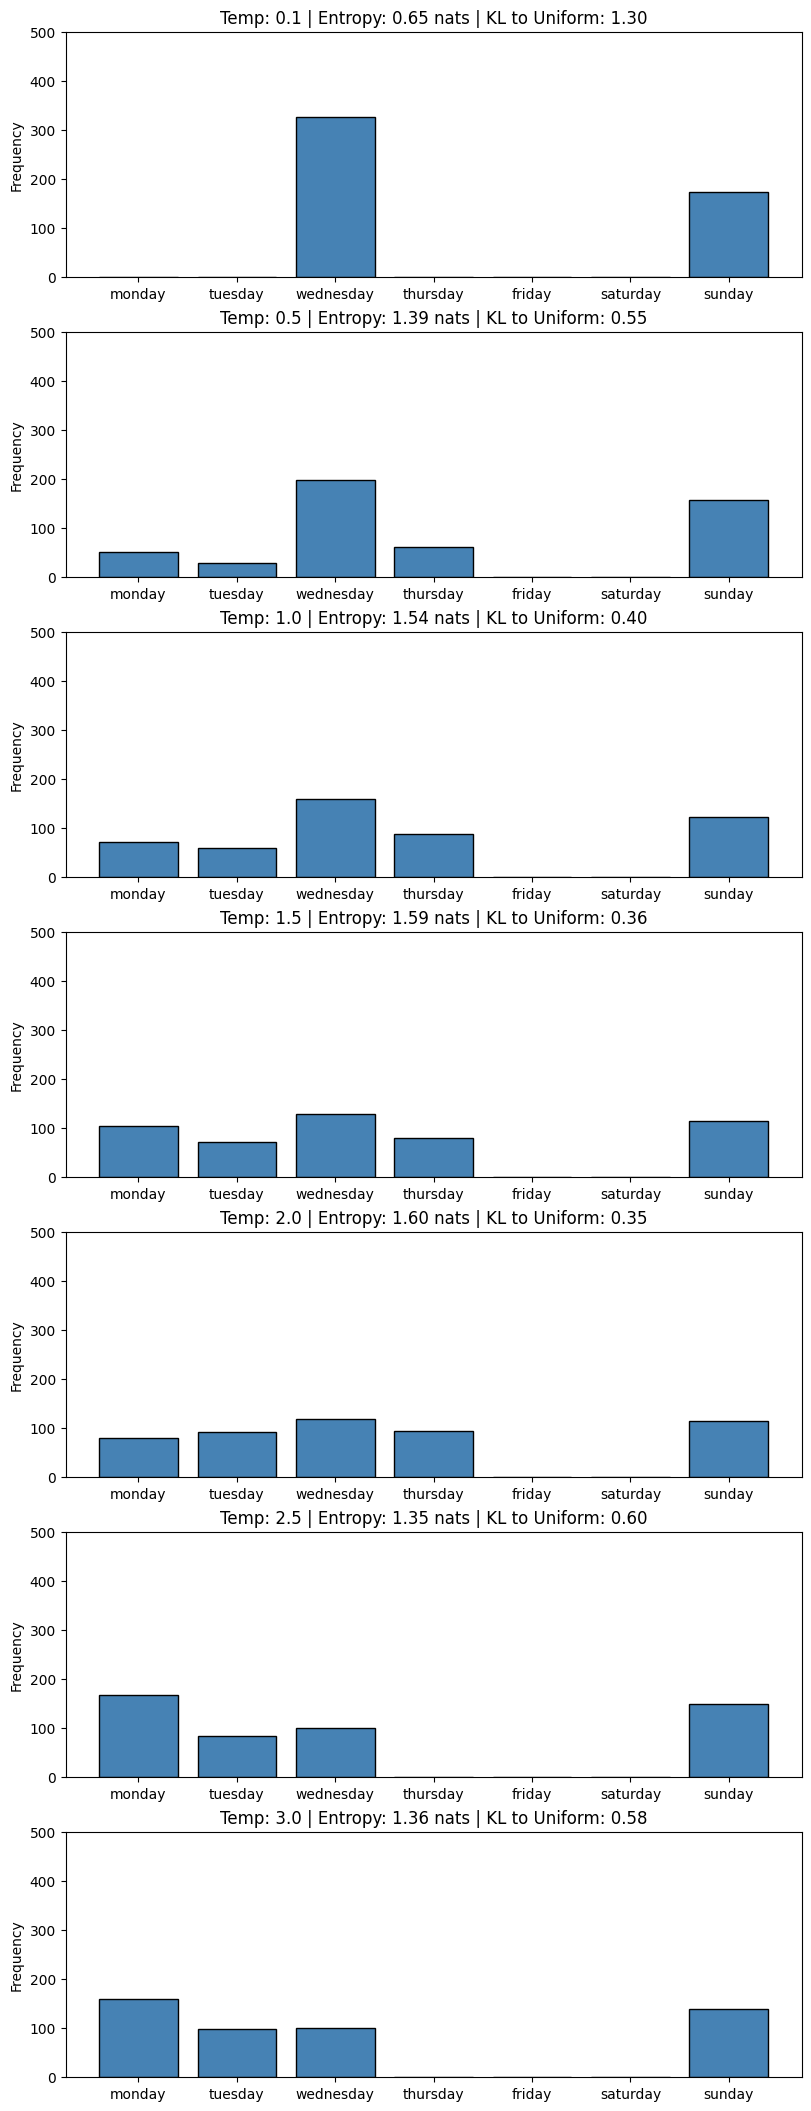

In [6]:
fig, axes = plt.subplots(len(TEMPERATURES), 1, figsize=(8, 3 * len(TEMPERATURES)), constrained_layout = True)

for i, temp in enumerate(TEMPERATURES):
    subset = df[df['temperature'] == temp]
    counts = Counter(subset['answer'])

    entropy = entropy_from_counts(counts)
    kl_div = kl_to_uniform(counts, VALID_DAYS)

    plot_counts = [counts.get(day, 0) for day in VALID_DAYS]

    invalid_count = sum(c for k, c in counts.items() if k not in VALID_DAYS)
    if invalid_count > 0:
        print(f"Warning: {invalid_count} invalid answers at T = {temp}")

    axes[i].bar(VALID_DAYS, plot_counts, color = 'steelblue', edgecolor = 'black')
    axes[i].set_title(f"Temp: {temp} | Entropy: {entropy:.2f} nats | KL to Uniform: {kl_div:.2f}")
    axes[i].set_ylabel("Frequency")
    axes[i].set_ylim(0, SAMPLES)

plt.show()

Try 1
    "Return a day of the week in lowercase. "
    "Output only the weekday (no additional text). "
    "For example, you would output: saturday"

Try 2
    "Select exactly one day of the week from this list: "
    "[thursday, tuesday, saturday, sunday, wednesday, monday, friday]. "
    "You must pick a day completely at random. Be entirely unpredictable. "
    "Output only the lowercase day name, nothing else."

Try 3
    "Imagine you have a fair, 7-sided die. You roll it. "
    "If it lands on 1, the answer is monday. "
    "If it lands on 2, the answer is tuesday. "
    "If it lands on 3, the answer is wednesday. "
    "If it lands on 4, the answer is thursday. "
    "If it lands on 5, the answer is friday. "
    "If it lands on 6, the answer is saturday. "
    "If it lands on 7, the answer is sunday. "
    "Tell me the day that corresponds to the number you rolled. "
    "Output ONLY the lowercase day name. No punctuation, no explanation."

Try 4
    "Return a day of the week in lowercase. "
    "Output only the weekday (no additional text). "
    "Don't forget that friday and saturday are also valid days! "
    "For example, you would output: saturday"

Try 5
    "Name exactly one day of the week. "
    "Just provide the lowercase name of the day and absolutely no other text, punctuation, or code. "
    "Do not write a script. "
    "Remember that friday and saturday are valid options."

Try 8
    hi! can you give me a random day of the week? reply with just the word (e.g., 'tuesday')

#### I.2 | Next-Token Probabilities and Top-K
We investigate the next-token probabilities to see how they compare to the observed frequency of responses in I.1. Fortunately, `qwen2.5:7b` is able to return `logprobs` with a ceiling near 20 tokens.


Day		Internal Prob	Observed Prob
--------------------------------------------------
Monday         0.2387		0.1420
Tuesday        0.0986		0.1180
Wednesday      0.1127		0.3180
Thursday       0.0551		0.1760
Friday         0.4015		0.0000
Saturday       0.0229		0.0000
Sunday         0.0705		0.2460


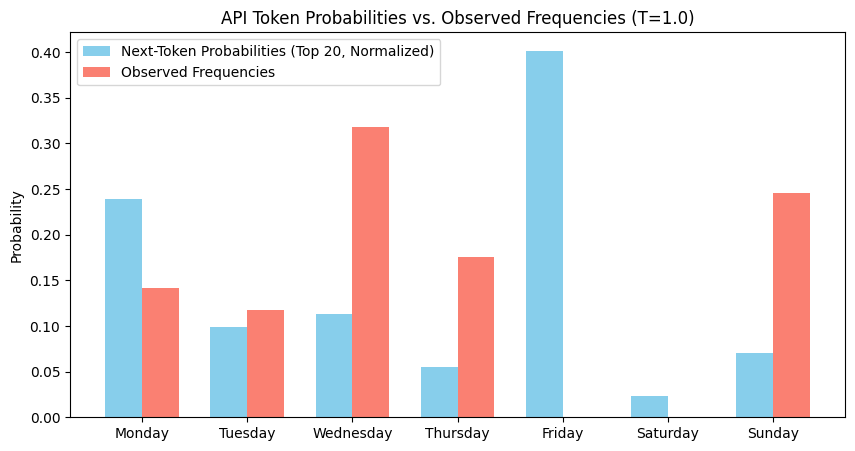

In [106]:
# 1. Fetch exact API logprobs using original prompt from Try #1.
payload = {
    "model": "qwen2.5:7b", 
    "prompt": "Return a day of the week in lowercase. Output only the weekday (no additional text). For example, you would output: saturday",
    "stream": False,
    "logprobs": True,
    "top_logprobs": 20,
    "options": {
        "temperature": 1.0,
        "num_predict": 1
    }
}

response = requests.post("http://localhost:11434/api/generate", json=payload)
data = response.json()

# 2. Extract and Normalize
raw_probs = {day: 0.0 for day in VALID_DAYS}

if 'logprobs' in data and len(data['logprobs']) > 0:
    for item in data['logprobs'][0].get('top_logprobs', []):
        raw_token = item['token']
        logprob = item['logprob']
        
        ans = normalize_answer(raw_token)
        clean_token = ans.split()[0] if ans else "invalid"
        
        if clean_token in VALID_DAYS:
            raw_probs[clean_token] += np.exp(logprob)

# Normalize
total_prob = sum(raw_probs.values())
internal_probs = {day: (raw_probs[day] / total_prob) if total_prob > 0 else 0 for day in VALID_DAYS}

# Compare with Observed data
df = pd.read_csv('working/part1_calibration_try1.csv')
df_temp1 = df[df['temperature'] == 1.0]
counts = Counter(df_temp1['answer'])
total_samples = sum(counts.values())
Observed_probs = {day: counts.get(day, 0) / total_samples for day in VALID_DAYS}

# Print
print("\nDay\t\tInternal Prob\tObserved Prob")
print("-" * 50)
for day in VALID_DAYS:
    print(f"{day.capitalize():<15}{internal_probs[day]:.4f}\t\t{Observed_probs[day]:.4f}")

# Plot
x = np.arange(len(VALID_DAYS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, [internal_probs[d] for d in VALID_DAYS], width, label='Next-Token Probabilities (Top 20, Normalized)', color='skyblue')
ax.bar(x + width/2, [Observed_probs[d] for d in VALID_DAYS], width, label='Observed Frequencies', color='salmon')

ax.set_ylabel('Probability')
ax.set_title('API Token Probabilities vs. Observed Frequencies (T=1.0)')
ax.set_xticks(x)
ax.set_xticklabels([d.capitalize() for d in VALID_DAYS])
ax.legend()

plt.show()

#### I.3 | Fruits that Start with B
Am I one of them? Now, we explore via the same experiemental pipeline a more difficult Scattergories question. Again, we will sample 500 generations per temperature, build histograms, and compute diversity metrics.

In [ ]:
from tqdm import tqdm

PROMPT = (
    "We are playing a game of Scattergories. "
    "The category is 'Fruits' and the letter is 'B'. "
    "What is a fruit that starts with the letter 'B'? "
    "Output only the lowercase word: no puncuation, no explanation. "
    "For example, 'banana'"
)

results = []

for temp in TEMPERATURES:
    print(f"Running Temp: {temp}")
    counts = Counter()
    
    for i in tqdm(range(SAMPLES), desc="Generating"):
        raw_ans = ollama_generate(
            model=MODEL,
            prompt=prompt,
            temperature=temp,
            top_k=40,
            max_tokens=10
        )
        
        ans = normalize_answer(raw_ans)
        ans = ans.split()[-1] if ans else "invalid" 
        
        counts[ans] += 1
        results.append({
            "prompt_type": "scattergories",
            "temperature": temp,
            "raw": raw_ans,
            "answer": ans
        })
        
    print(f"Result: {len(counts)} unique fruits found.")
    print(f"Top 3 choices: {counts.most_common(3)}")

df = pd.DataFrame(results)
df.to_csv('working/part1_scattergories.csv', index=False)

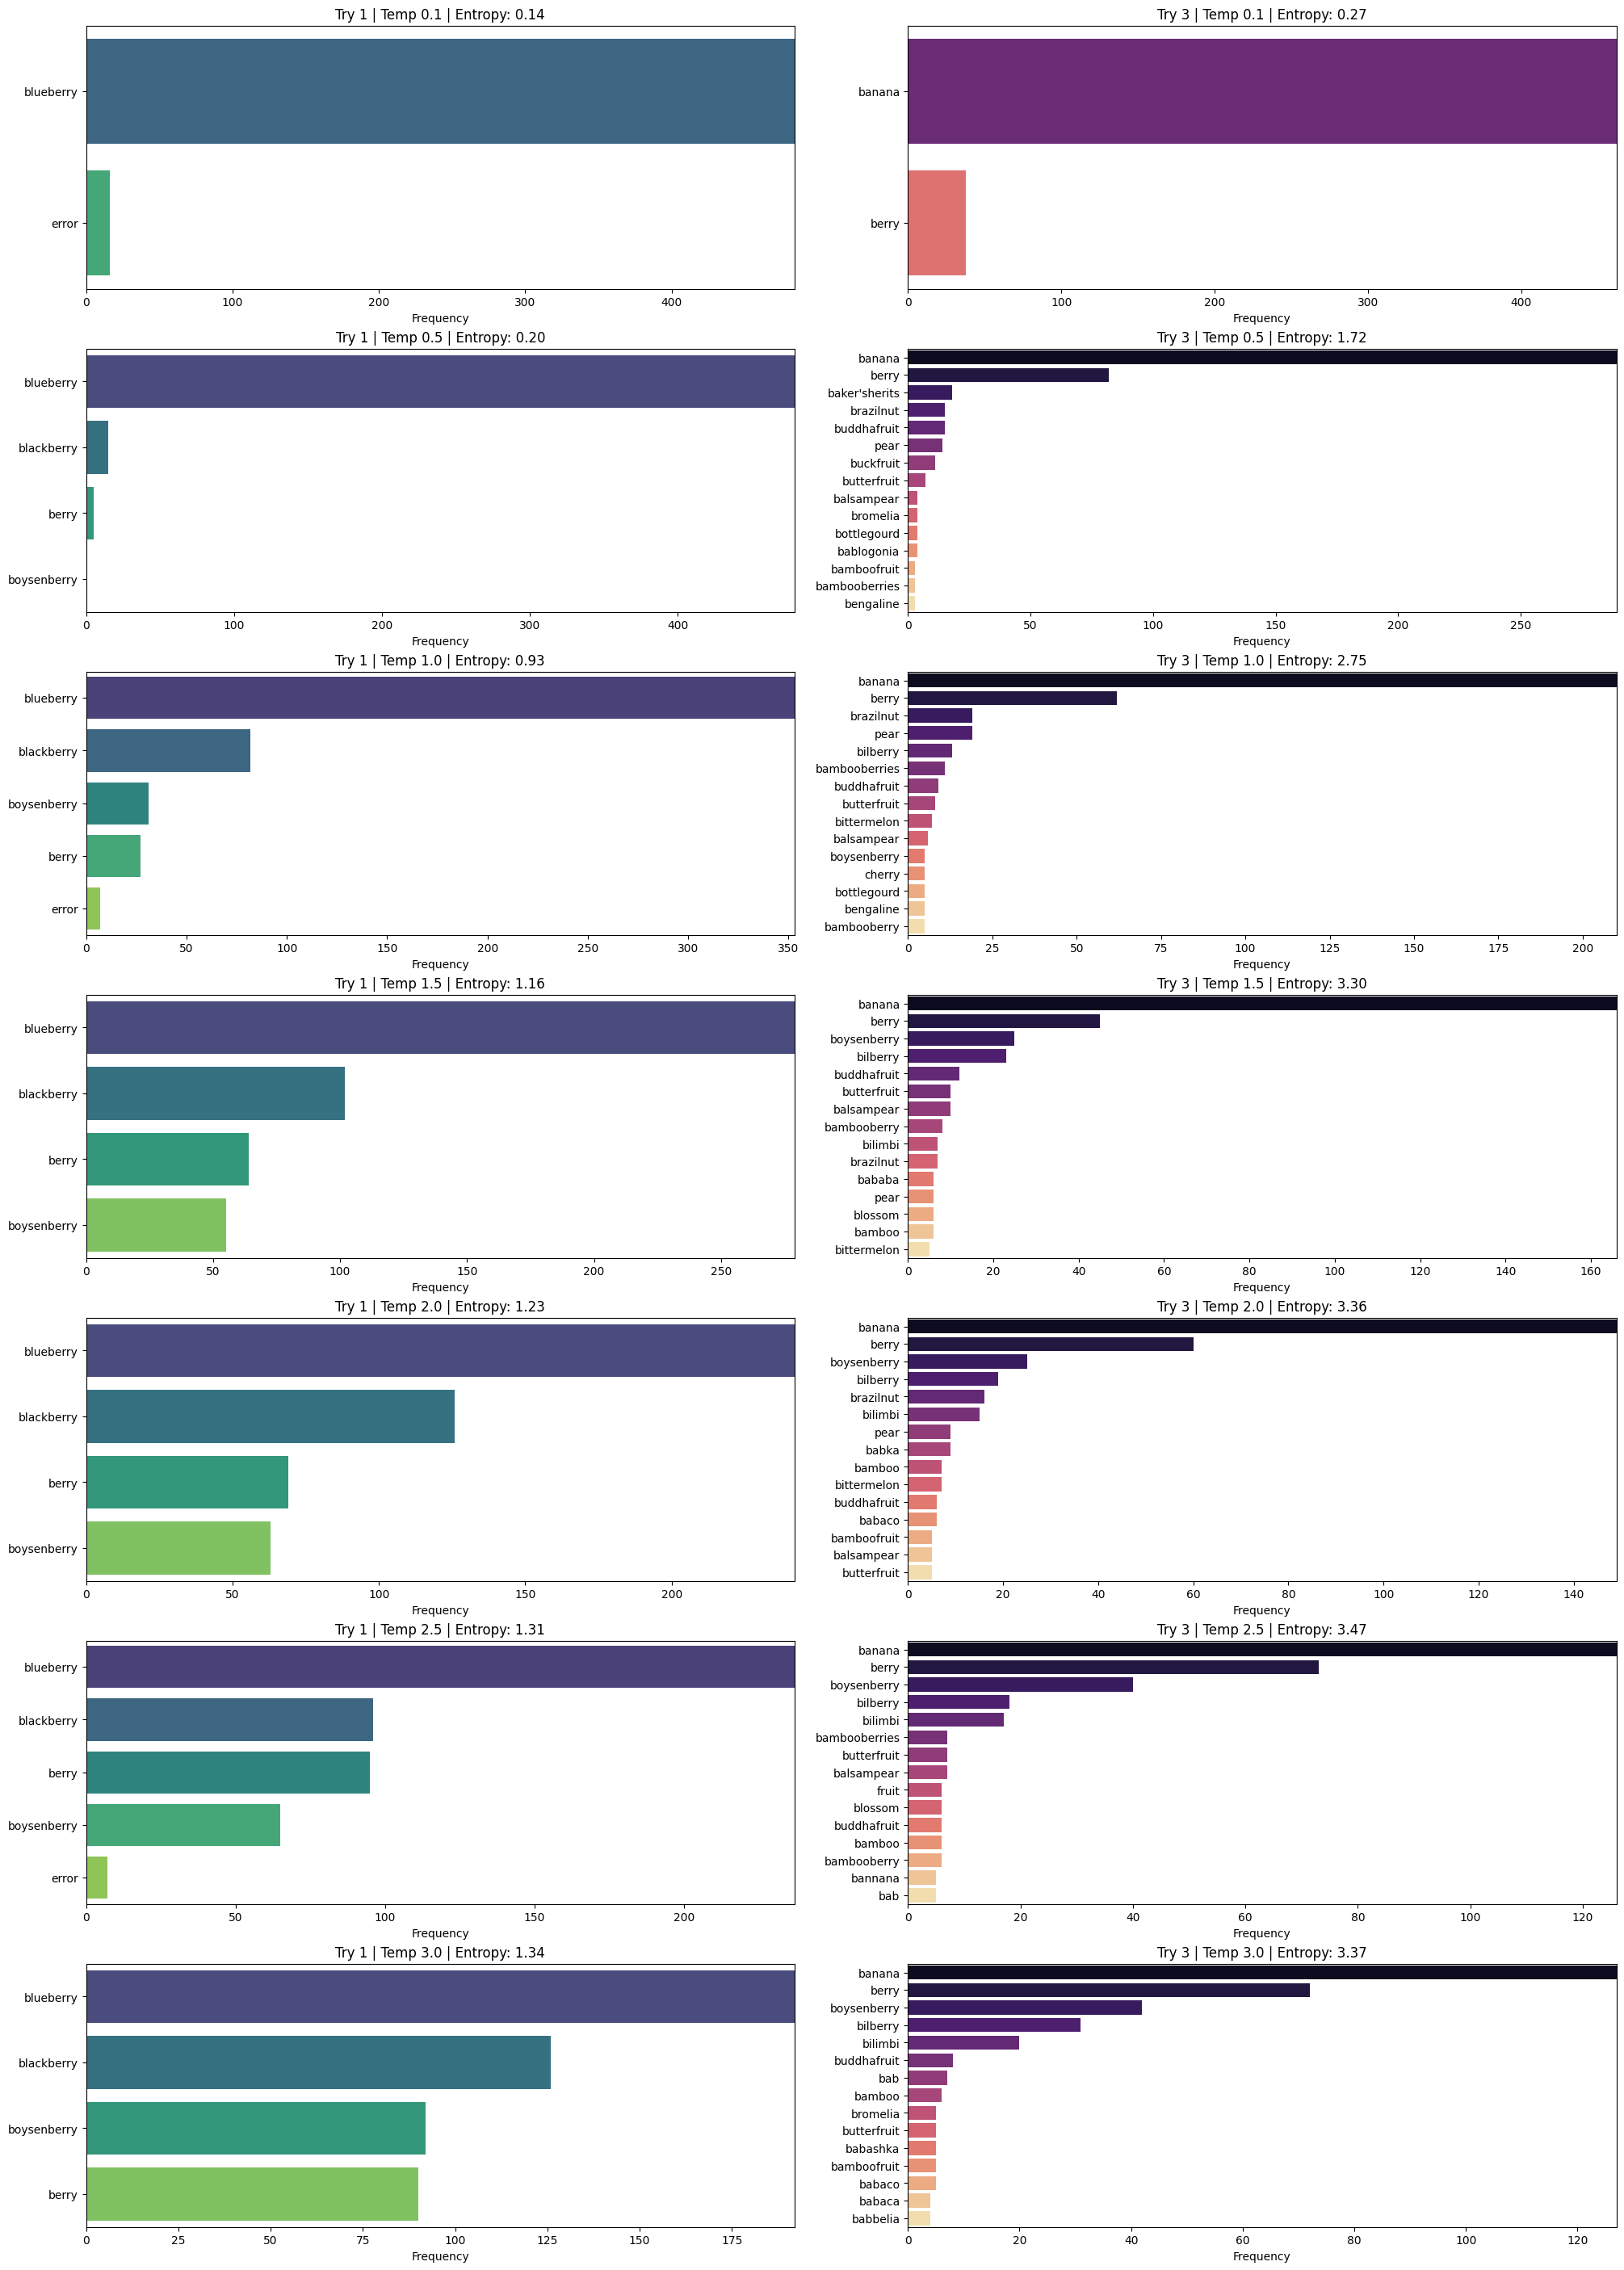

In [109]:
import seaborn as sns

df1 = pd.read_csv('working/part1_scattergories_try1.csv')
df2 = pd.read_csv('working/part1_scattergories_try3.csv')

temps = sorted(df1['temperature'].unique())

def get_metrics(df):
    metrics = []
    for temp in temps:
        subset = df[df['temperature'] == temp]
        counts = Counter(subset['answer'])
        
        unique_count = len(counts)
        # Using your entropy function:
        ent = entropy_from_counts(counts) if len(counts) > 0 else 0
        
        if counts:
            top_fruit, top_freq = counts.most_common(1)[0]
        else:
            top_fruit, top_freq = "N/A", 0
            
        metrics.append({
            "Temperature": temp,
            "Unique Fruits": unique_count,
            "Entropy": ent,
            "Most Common": top_fruit,
            "Top Freq": top_freq / len(subset) if len(subset) > 0 else 0
        })
    return pd.DataFrame(metrics)

metrics_df1 = get_metrics(df1)
metrics_df2 = get_metrics(df2)

fig, axes = plt.subplots(len(temps), 2, figsize=(20, 4 * len(temps)), constrained_layout=True)

for i, temp in enumerate(temps):
    # --- LEFT COLUMN (Try 1) ---
    subset1 = df1[df1['temperature'] == temp]
    counts1 = Counter(subset1['answer']).most_common(15)
    labels1 = [c[0] for c in counts1]
    values1 = [c[1] for c in counts1]
    
    sns.barplot(x=values1, y=labels1, ax=axes[i, 0], palette="viridis", hue=labels1, legend=False)
    ent1 = metrics_df1.iloc[i]['Entropy']
    axes[i, 0].set_title(f"Try 1 | Temp {temp} | Entropy: {ent1:.2f}")
    axes[i, 0].set_xlabel("Frequency")
    axes[i, 0].set_xlim(0, max(values1 + [1]))
    
    # --- RIGHT COLUMN (Try 3) ---
    subset2 = df2[df2['temperature'] == temp]
    counts2 = Counter(subset2['answer']).most_common(15)
    labels2 = [c[0] for c in counts2]
    values2 = [c[1] for c in counts2]
    
    sns.barplot(x=values2, y=labels2, ax=axes[i, 1], palette="magma", hue=labels2, legend=False)
    ent2 = metrics_df2.iloc[i]['Entropy']
    axes[i, 1].set_title(f"Try 3 | Temp {temp} | Entropy: {ent2:.2f}")
    axes[i, 1].set_xlabel("Frequency")
    axes[i, 1].set_xlim(0, max(values2 + [1]))

plt.show()


In [112]:
unique_1 = df1.groupby('temperature')['answer'].nunique().reset_index()
unique_1.columns = ['Temperature', 'Prompt 1 (Simple)']

unique_2 = df2.groupby('temperature')['answer'].nunique().reset_index()
unique_2.columns = ['Temperature', 'Prompt 3 (No Blueberry)']

comparison_df = pd.merge(unique_1, unique_2, on='Temperature')

print(comparison_df.to_string(index=False))

 Temperature  Prompt 1 (Simple)  Prompt 3 (No Blueberry)
         0.1                  2                        2
         0.5                  4                       35
         1.0                  5                       79
         1.5                  4                      107
         2.0                  4                      110
         2.5                  5                      126
         3.0                  4                      119


Prompt 1
    "We are playing a game of Scattergories. "
    "The category is 'Fruits' and the letter is 'B'. "
    "What is a fruit that starts with the letter 'B'? "
    "Output only the lowercase word: no puncuation, no explanation. "
    "For example, 'banana'"

Prompt 2
    "What is a fruit that starts with the letter 'B'? "
    "Output only the lowercase word: no puncuation, no explanation. "
    "For example, 'banana'"

Prompt 3
    "What is a fruit that starts with the letter 'B'? "
    "Output only the lowercase word: no puncuation, no explanation. "
    "Do not say blueberry. "
    "For example, 'banana'"